In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
# 1. .env を読み込む
load_dotenv(override=True)
# 2. .env から「CSVの場所」を引っ張ってくる
csv_path = os.getenv('NETFLIX_CSV_PATH')
# 3. 引っ張ってきたパスを使って、いつも通りCSVを読み込む！
df_netflix = pd.read_csv(csv_path)

# 英語の文字列を綺麗にdatetime型（日付型）に変換する
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], format='mixed')
# 「年」と「月」の切り出し
df_netflix['added_year'] = df_netflix['date_added'].dt.year.astype('Int64')  # 年は整数型に変換
df_netflix['added_month'] = df_netflix['date_added'].dt.month.astype('Int64')  # 月も整数型に変換
df_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


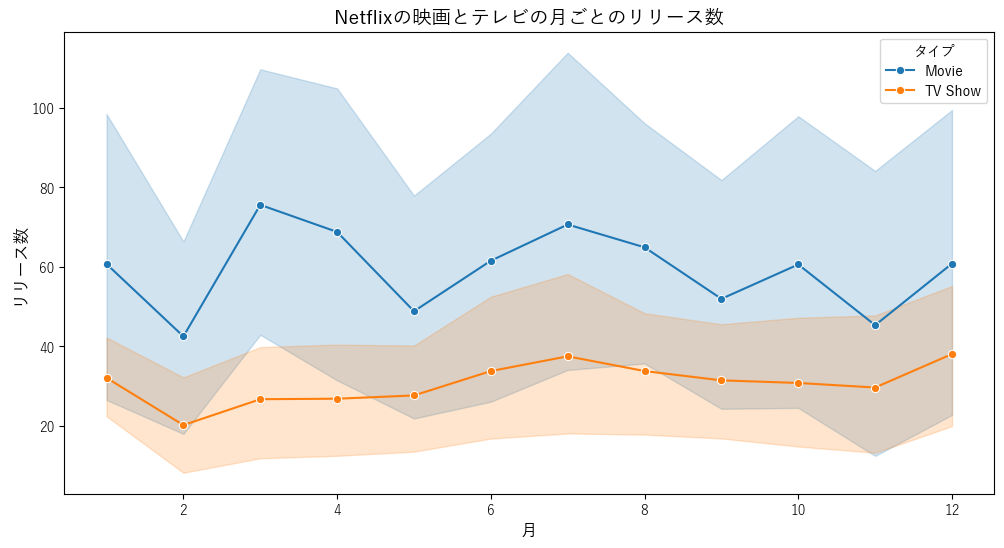

In [ ]:
#月単位でリリース数を映画とテレビで分けて折れ線グラフを作る
import matplotlib.pyplot as plt
import seaborn as sns
# 日本語フォントの設定
from matplotlib import font_manager
font_path = 'C:/Windows/Fonts/YuGothM.ttc'  # 適切な日本語フォントのパスを指定
font_prop = font_manager.FontProperties(fname=font_path)
# 映画とテレビで月ごとのリリース数を集計
monthly_counts = df_netflix.groupby(['added_year', 'added_month', 'type']).size().reset_index(name='count')
# グラフの作成
plt.figure(figsize=(6, 3))
plt.rcParams['font.family'] = font_prop.get_name() # 全体の基本フォントを遊ゴシックにする
plt.rcParams['axes.unicode_minus'] = False          # マイナス記号が文字化けするのを防ぐ
#hue='type'で映画とテレビを色分けして折れ線グラフを描く
sns.lineplot(data=monthly_counts, x='added_month', y='count', hue='type', marker='o')
# グラフの装飾 - 日本語フォントの適用
ax = plt.gca()
ax.set_title("Netflixの映画とテレビの月ごとのリリース数", fontproperties=font_prop, fontsize=14, fontweight='bold')
ax.set_xlabel("月", fontproperties=font_prop, fontsize=12)
ax.set_ylabel("リリース数", fontproperties=font_prop, fontsize=12)  
# 凡例のフォントも日本語に対応させる
legend = ax.legend(title='タイプ', title_fontproperties=font_prop, prop=font_prop)

plt.show()



In [14]:
#country列のデータの入り方を確認する、1国だけか、複数国が入っているか
print(df_netflix['country'].head(10))
#countyの中身を分解して縦持ちにする
df_netflix_exploded = df_netflix.assign(country=df_netflix['country'].str.split(', ')).explode('country')

0                                        United States
1                                         South Africa
2                                              Unknown
3                                              Unknown
4                                                India
5                                              Unknown
6                                              Unknown
7    United States, Ghana, Burkina Faso, United Kin...
8                                       United Kingdom
9                                        United States
Name: country, dtype: str


C:\Users\user\AppData\Local\Temp\ipykernel_4228\220895948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')


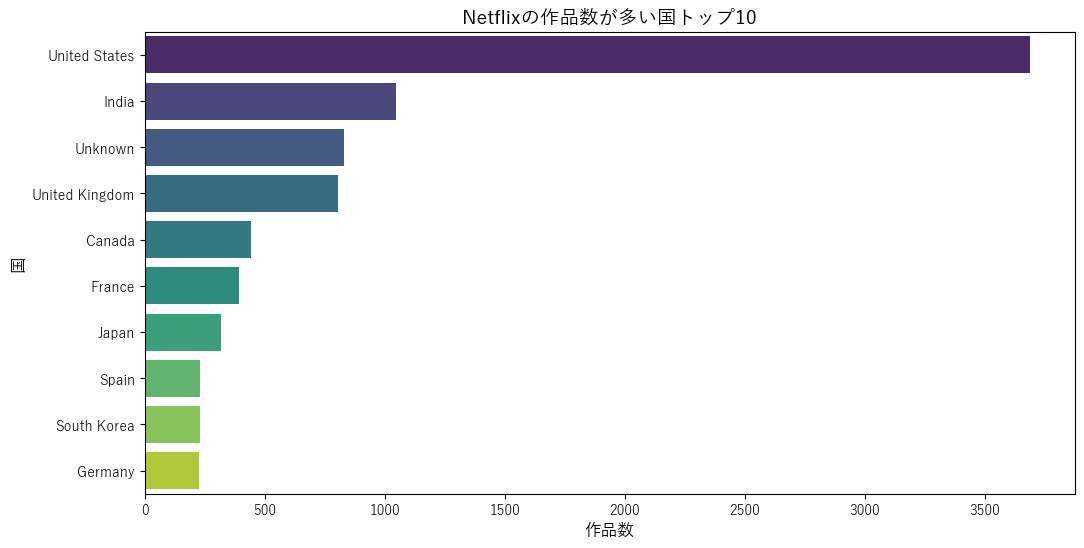

In [15]:
#country列の値をカウントして、上位10か国を棒グラフで表示する
country_counts = df_netflix_exploded['country'].value_counts().head(10) 
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = font_prop.get_name() # 全体の基本フォントを遊ゴシックにする
plt.rcParams['axes.unicode_minus'] = False          # マイナス記号が文字化けするのを防ぐ
sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')
plt.title("Netflixの作品数が多い国トップ10", fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.xlabel("作品数", fontproperties=font_prop, fontsize=12) 
plt.ylabel("国", fontproperties=font_prop, fontsize=12)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_4228\3614084085.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[count for genre, count in top_genres], y=[genre for genre, count in top_genres], palette='magma')


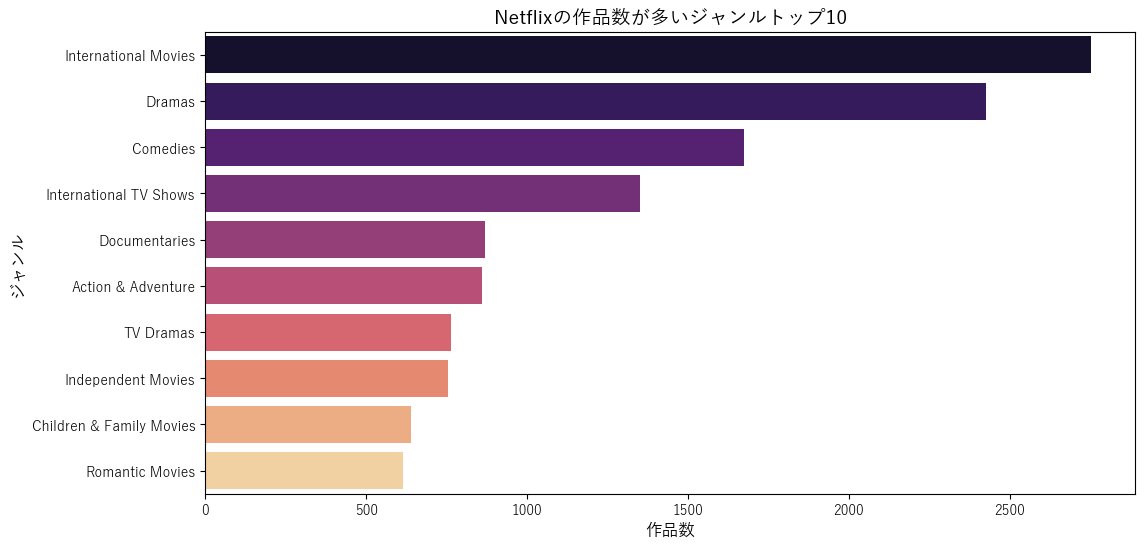

In [4]:
#listed_inの中身を単語に分解して、ジャンルごとの作品数をカウントして、上位10ジャンルを棒グラフで表示する
from collections import Counter
# listed_in列を単語に分解してリスト化
genre_list = df_netflix['listed_in'].dropna().apply(lambda x: [genre.strip() for genre in x.split(',')])
# ジャンルごとの作品数をカウント    
genre_counts = Counter([genre for sublist in genre_list for genre in sublist])
top_genres = genre_counts.most_common(10)
# グラフの作成
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = font_prop.get_name() # 全体の基本フォントを遊ゴシックにする
plt.rcParams['axes.unicode_minus'] = False          # マイナス記号が文字化けするのを防ぐ
sns.barplot(x=[count for genre, count in top_genres], y=[genre for genre, count in top_genres], palette='magma')
plt.title("Netflixの作品数が多いジャンルトップ10", fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.xlabel("作品数", fontproperties=font_prop, fontsize=12)
plt.ylabel("ジャンル", fontproperties=font_prop, fontsize=12)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_4228\2412866990.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_days.index, y=top_days.values, palette='coolwarm')


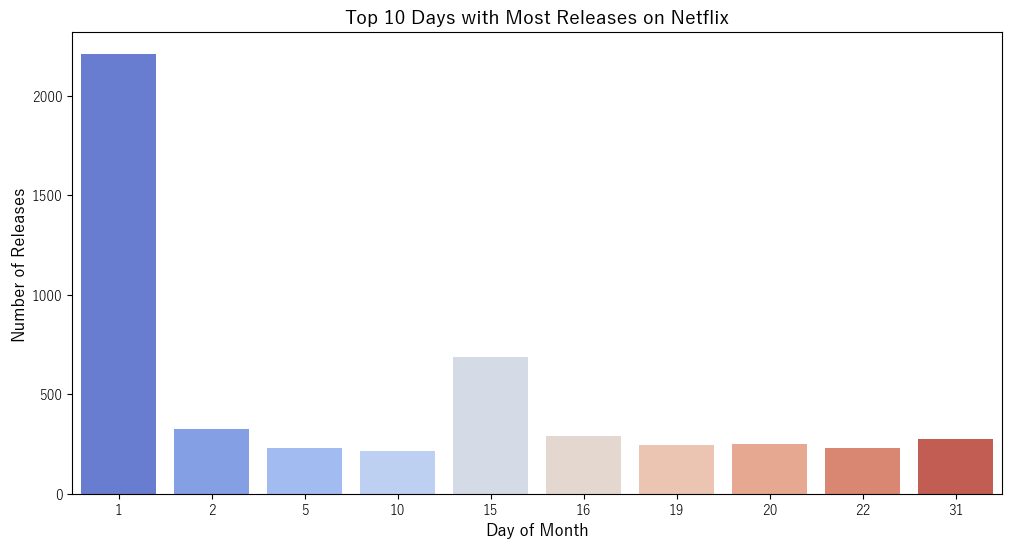

In [5]:
#毎月何日くらいの作品が多いのかを調べるために、date_added列から日付を切り出して、日付ごとの作品数をカウントして、上位10日を棒グラフで表示する
# date_added列から日付を切り出す
df_netflix['added_day'] = df_netflix['date_added'].dt.day.astype('Int64')  # 日付も整数型に変換
# 日付ごとの作品数をカウント
day_counts = df_netflix['added_day'].value_counts().sort_index()
#countを軸に降順に並べ替える
day_counts = day_counts.sort_values(ascending=False)
top_days = day_counts.head(10) 
# グラフの作成
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = font_prop.get_name() # 全体の基本フォントを遊ゴシックにする
plt.rcParams['axes.unicode_minus'] = False          # マイナス記号が文字化けするのを防ぐ
sns.barplot(x=top_days.index, y=top_days.values, palette='coolwarm')
plt.title('Top 10 Days with Most Releases on Netflix', fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.xlabel('Day of Month', fontproperties=font_prop, fontsize=12)
plt.ylabel('Number of Releases', fontproperties=font_prop, fontsize=12)
plt.show()

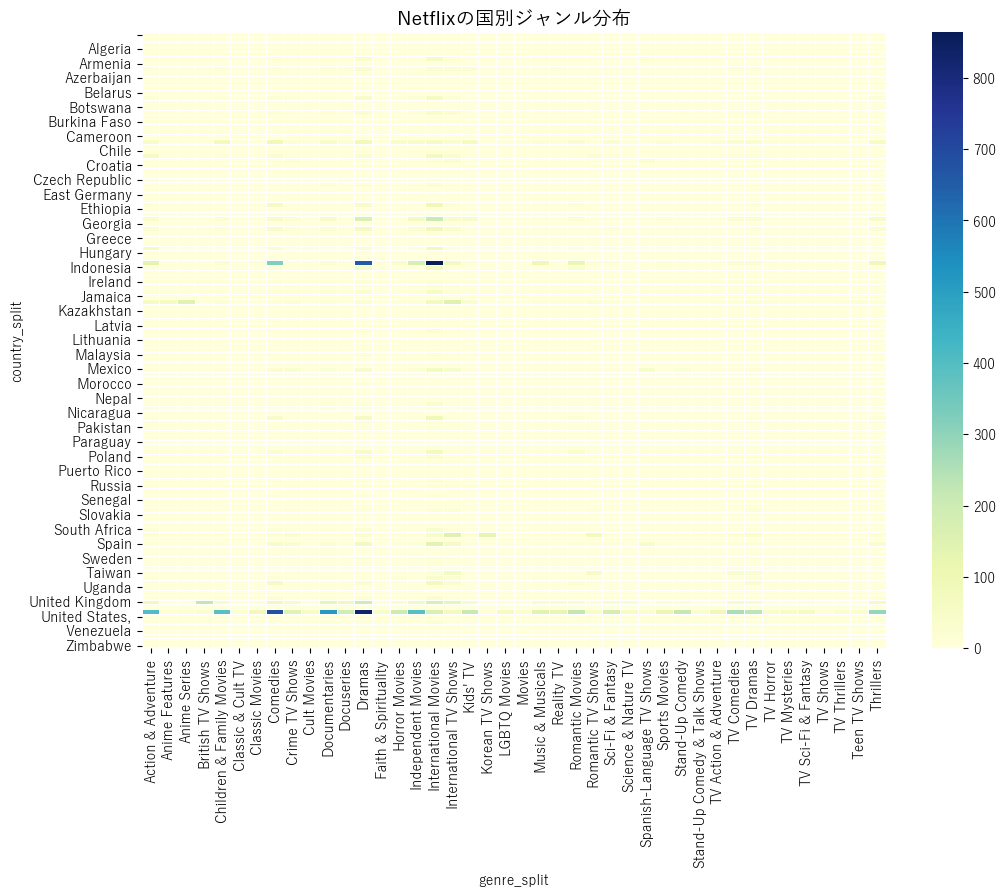

In [6]:
# 💡 プロが実務で書く「for文なし」の爆速ジャンル集計コード
# 1. カンマ区切りの文字列をリストに変換する
df_netflix['genre_split'] = df_netflix['listed_in'].dropna().str.split(', ')
df_netflix['country_split'] = df_netflix['country'].dropna().str.split(', ')
# 2. 【魔法の1行】リストを展開して、ジャンルごとに自動で「行」を増やしてくれる！
df_exploded = df_netflix.explode('genre_split').explode('country_split')  # ジャンルを展開した後、国も展開する
# 3. 縦に伸びたデータを使って、一気にピボットテーブルを作る
pivot_table = df_exploded.pivot_table(index='country_split', columns='genre_split', aggfunc='size', fill_value=0)
pivot_table.head() # 上位5カ国だけチラ見してみる
# 4. 国別のジャンル分布をヒートマップで可視化する
plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = font_prop.get_name() # 全体の基本フォ
plt.rcParams['axes.unicode_minus'] = False          # マイナス記号が文字化けするのを防ぐ
sns.heatmap(pivot_table, cmap='YlGnBu', linewidths=.5)
plt.title('Netflixの国別ジャンル分布', fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.show()

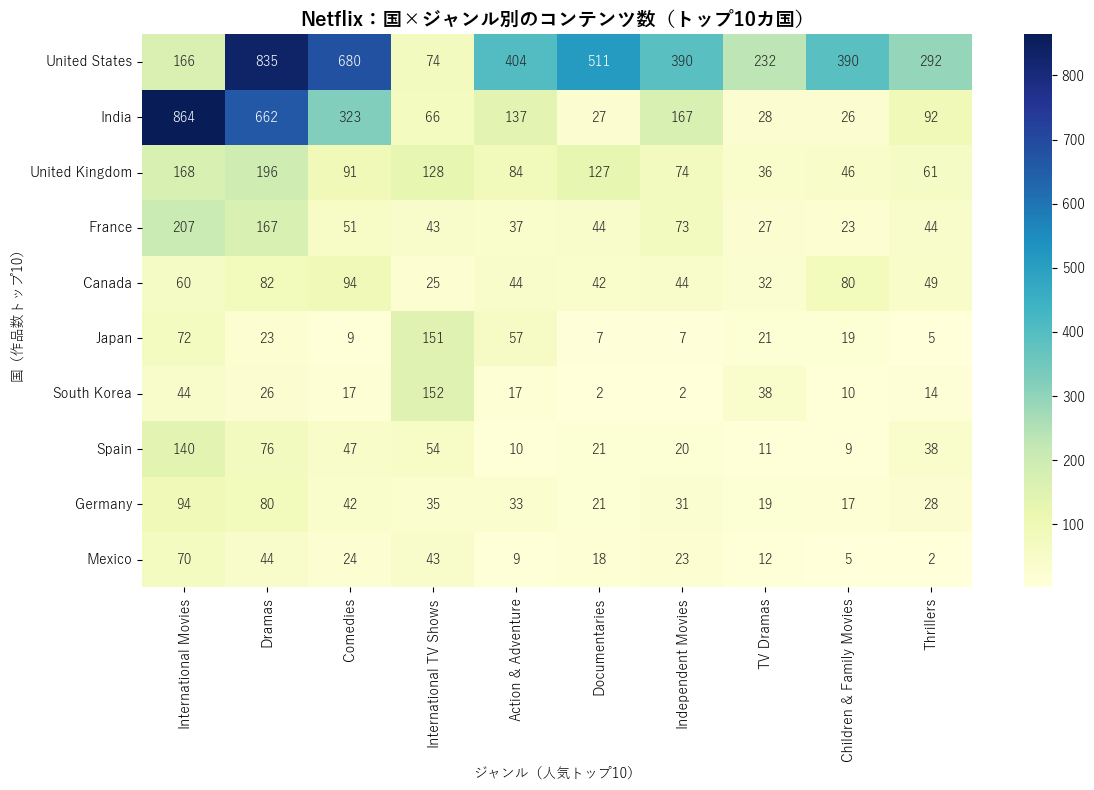

In [7]:
# 1. 国名とジャンルを、それぞれカンマで区切って「リスト」に変換する
df_netflix['country_list'] = df_netflix['country'].dropna().str.split(', ')
df_netflix['genre_list'] = df_netflix['listed_in'].dropna().str.split(', ')

# 2. 国名とジャンルでデータを「爆発（縦展開）」させる
df_multi_exploded = df_netflix.explode('country_list').explode('genre_list')

# 3. 完璧にバラバラになったデータで、まずは全体のピボットテーブルを作成
pivot_table = df_multi_exploded.pivot_table(
    index='country_list', 
    columns='genre_list', 
    aggfunc='size', 
    fill_value=0
)

# 💡 【ここがポイント！】作品数が多い「トップ10カ国」の名前を自動で取得する
# .value_counts().head(10).index と書くだけで、['United States', 'India', 'United Kingdom', ...] というリストが作れます
top_countries = df_multi_exploded['country_list'].value_counts().head(10).index

# 💡 【おまけ】ジャンルも多すぎると見づらいので、人気の「トップ10ジャンル」も取得する
top_genres = df_multi_exploded['genre_list'].value_counts().head(10).index

# 4. 【フィルタリング】ピボットテーブルから、トップ10の国とジャンル「だけ」を抜き出す！
# .loc[縦軸のリスト, 横軸のリスト] を使うと、指定した行列だけを綺麗に切り出せます
plot_data = pivot_table.loc[top_countries, top_genres]

# 5. ヒートマップを描く
plt.figure(figsize=(12, 8))
plt.rcParams['font.family'] = font_prop.get_name() # 日本語フォント対策

# annot=Trueでマスの中に数字を表示、fmt='d'で整数表示、cmapで色合いを設定
sns.heatmap(plot_data, annot=True, fmt='d', cmap='YlGnBu') 

plt.title("Netflix：国×ジャンル別のコンテンツ数（トップ10カ国）", fontsize=14, fontweight='bold')
plt.ylabel("国（作品数トップ10）")
plt.xlabel("ジャンル（人気トップ10）")
plt.tight_layout() # 文字が画面からはみ出るのを防ぐ魔法の1行
plt.show()

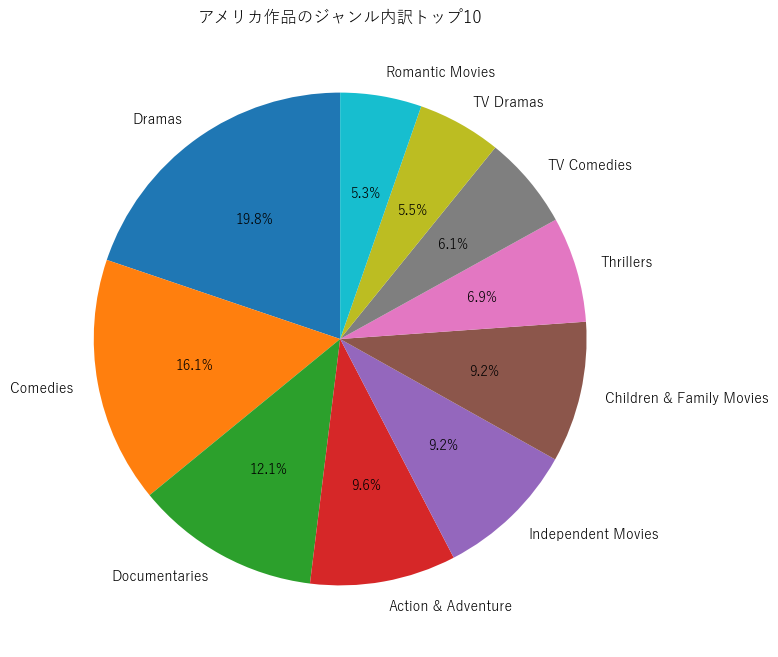

In [8]:
# 💡 アメリカだけのデータを抜き出して、ジャンルの割合を数える
us_data = df_multi_exploded[df_multi_exploded['country_list'] == 'United States']
us_genre_pct = us_data['genre_list'].value_counts(normalize=True).head(10) # normalize=Trueで割合(%)になる

# 円グラフで可視化してみる
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.pie(us_genre_pct, labels=us_genre_pct.index, autopct='%1.1f%%', startangle=90)
plt.title("アメリカ作品のジャンル内訳トップ10")
plt.show()

In [9]:
# 💡 'United States' を含むかどうかで、True/False の2グループに分ける
df_multi_exploded['is_usa'] = df_multi_exploded['country_list'] == 'United States'
df_multi_exploded.head() # is_usa列が追加されているのを確認してみる

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year,added_month,added_day,genre_split,country_split,country_list,genre_list,is_usa
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,25,[Documentaries],[United States],United States,Documentaries,True
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24,"[International TV Shows, TV Dramas, TV Mysteries]",[South Africa],South Africa,International TV Shows,False
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24,"[International TV Shows, TV Dramas, TV Mysteries]",[South Africa],South Africa,TV Dramas,False
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,24,"[International TV Shows, TV Dramas, TV Mysteries]",[South Africa],South Africa,TV Mysteries,False
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,24,"[Crime TV Shows, International TV Shows, TV Ac...",NaN,NaN,Crime TV Shows,False


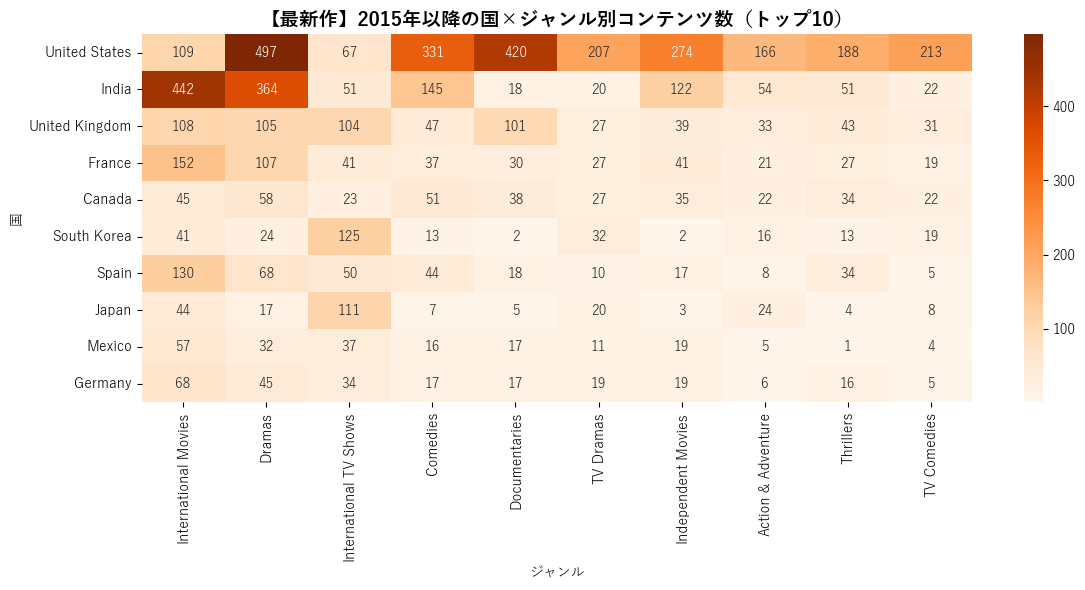

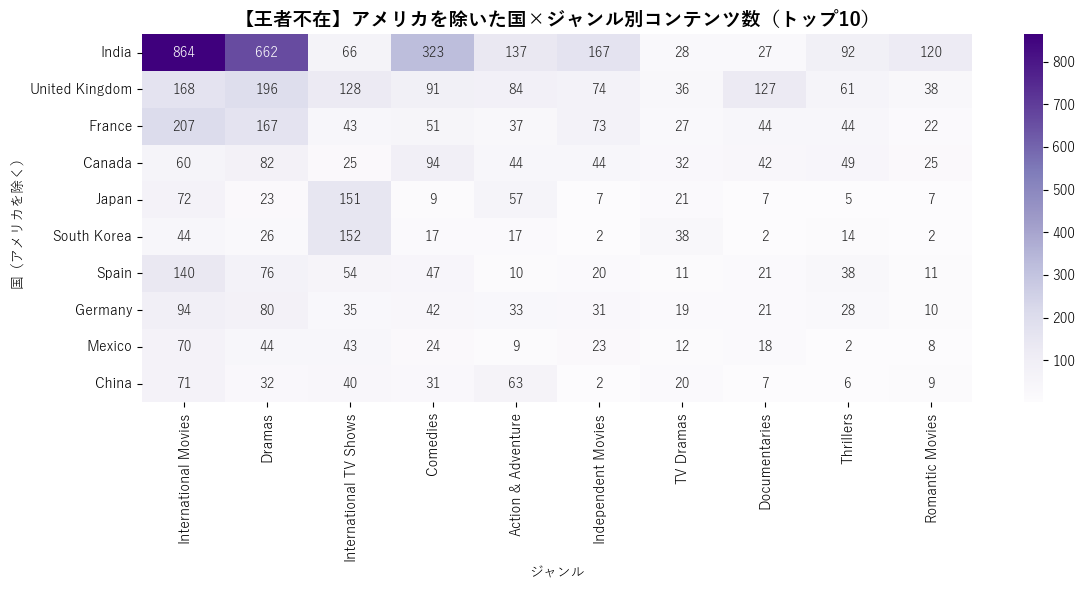

In [10]:
# ----------------------------------------------------
# ⏳ 【グラフA】2015年以降の「最新作だけ」のトップ10国
# ----------------------------------------------------
# 1. 2015年以降のデータに絞り込む
df_recent = df_multi_exploded[df_multi_exploded['release_year'] >= 2015]

# 2. 最新作の中でのトップ10カ国とトップ10ジャンルを抽出
top_countries_recent = df_recent['country_list'].value_counts().head(10).index
top_genres_recent = df_recent['genre_list'].value_counts().head(10).index

# 3. 専用のピボットテーブルを作成して切り出す
pivot_recent = df_recent.pivot_table(index='country_list', columns='genre_list', aggfunc='size', fill_value=0)
plot_data_recent = pivot_recent.loc[top_countries_recent, top_genres_recent]

# 📊 グラフAの描画
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = font_prop.get_name()
sns.heatmap(plot_data_recent, annot=True, fmt='d', cmap='Oranges') # 違いが分かりやすいようにオレンジ色に
plt.title("【最新作】2015年以降の国×ジャンル別コンテンツ数（トップ10）", fontsize=14, fontweight='bold')
plt.ylabel("国")
plt.xlabel("ジャンル")
plt.tight_layout()
plt.show()


# ----------------------------------------------------
# 🚫 【グラフB】王者を消し去った「アメリカ抜き」のトップ10国
# ----------------------------------------------------
# 1. アメリカ以外のデータに絞り込む
df_no_usa = df_multi_exploded[df_multi_exploded['country_list'] != 'United States']

# 2. アメリカを除いた中でのトップ10カ国とトップ10ジャンルを抽出
top_countries_no_usa = df_no_usa['country_list'].value_counts().head(10).index
top_genres_no_usa = df_no_usa['genre_list'].value_counts().head(10).index

# 3. 専用のピボットテーブルを作成して切り出す
pivot_no_usa = df_no_usa.pivot_table(index='country_list', columns='genre_list', aggfunc='size', fill_value=0)
plot_data_no_usa = pivot_no_usa.loc[top_countries_no_usa, top_genres_no_usa]

# 📊 グラフBの描画
plt.figure(figsize=(12, 6))
sns.heatmap(plot_data_no_usa, annot=True, fmt='d', cmap='Purples') # 違いが分かりやすいように紫色に
plt.title("【王者不在】アメリカを除いた国×ジャンル別コンテンツ数（トップ10）", fontsize=14, fontweight='bold')
plt.ylabel("国（アメリカを除く）")
plt.xlabel("ジャンル")
plt.tight_layout()
plt.show()

In [11]:
# 1. TV番組（TV Shows）だけのデータに絞り込む
df_tv = df_multi_exploded[df_multi_exploded['type'] == 'TV Show'].copy()

# 2. duration（「1 Season」などの文字）から、数字だけを抜き出して整数に変換する
df_tv['seasons'] = df_tv['duration'].str.extract('(\d+)').astype(float)

# 3. 国別に「総シーズン数」を合計して、多い順に並べる
country_seasons = df_tv.groupby('country_list')['seasons'].sum().sort_values(ascending=False)

# 上位10カ国を表示
print("【総シーズン数（ボリューム）の国別ランキング】")
print(country_seasons.head(10))

【総シーズン数（ボリューム）の国別ランキング】
country_list
United States     4240.0
United Kingdom    1342.0
Canada             724.0
Japan              675.0
South Korea        582.0
France             315.0
Spain              310.0
Mexico             278.0
Australia          269.0
India              237.0
Name: seasons, dtype: float64


<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_4228\2645844516.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_tv['seasons'] = df_tv['duration'].str.extract('(\d+)').astype(float)


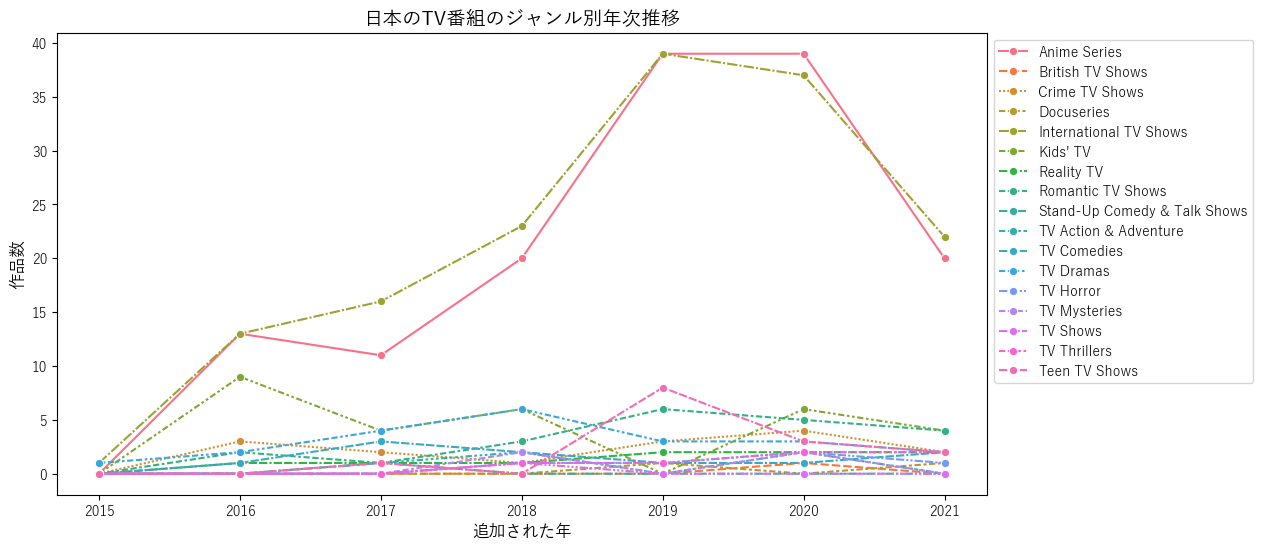

In [12]:
#日本だけに国を絞ってジャンルごとの年次推移のグラフを作る
df_tv_jp = df_tv[df_tv['country_list'] == 'Japan']
# 年ごとにジャンルの数をカウントするためのピボットテーブルを作成
pivot_jp = df_tv_jp.pivot_table(index='added_year', columns='genre_list', aggfunc='size', fill_value=0)
# グラフの作成  
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = font_prop.get_name() # 日本語フォント対策
plt.rcParams['axes.unicode_minus'] = False          # マイナス記号が文字化けするのを防ぐ
sns.lineplot(data=pivot_jp, marker='o')
plt.title("日本のTV番組のジャンル別年次推移", fontproperties=font_prop, fontsize=14, fontweight='bold')
plt.xlabel("追加された年", fontproperties=font_prop, fontsize=12) 
plt.ylabel("作品数", fontproperties=font_prop, fontsize=12)
plt.legend(title='ジャンル', title_fontproperties=font_prop, prop=font_prop)
#legendの位置を最適化する
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()